# Evaluación del Modelo, Calibración Térmica y Extracción del Hold-Out

Este cuaderno ejecuta la auditoría final del modelo RoBERTa corporativo sobre el conjunto Hold-Out (Fold 5) estrictamente invisible durante el entrenamiento.

Dado que el particionado en el entrenamiento se realizó mediante `StratifiedGroupKFold` para evitar la fuga de datos por repetición de `INCIDENT_ID`, se reproduce iterativamente el mismo generador pseudoaleatorio (`random_state=42`) sobre el corpus maestro (`corpus_sitor_limpio.parquet`) para aislar matemáticamente los mismos tickets de test.

Se implementa además una calibración térmica mediante el optimizador L-BFGS (Broyden–Fletcher–Goldfarb–Shanno). Las redes neuronales profundas tienden a sufrir de *overconfidence* en sus *logits* de salida. L-BFGS escala la distribución térmica minimizando la función de pérdida empírica (Negative Log-Likelihood) sobre el Hold-Out, garantizando que el Softmax refleje probabilidades frecuentistas reales antes de inyectarlas en el simulador financiero.

In [ ]:
import json
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import scipy.optimize as optim
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# 1. Montaje de Entorno Cloud
drive.mount('/content/drive')
BASE_DIR = Path('/content/drive/MyDrive/MasterEvolve/Proyecto TFM/SITOR')

RUTA_GOLD = BASE_DIR / "data" / "gold" / "corpus_sitor_limpio.parquet"
DIR_RAIZ_MODELO = BASE_DIR / "src" / "models" / "roberta_corporativo"
DIR_PESOS = DIR_RAIZ_MODELO / "roberta_corporativo_final"
RUTA_MAPPING = DIR_RAIZ_MODELO / "label_mapping.json"

# Sanity Check de Arquitectura
if not DIR_PESOS.exists():
    raise FileNotFoundError(f"🚨 FATAL: No se encuentran los pesos en {DIR_PESOS}")

# 2. Reconstrucción Aislada del Fold 5
print("Cargando corpus maestro...")
df_gold = pd.read_parquet(RUTA_GOLD)

le = LabelEncoder()
target_encoded = le.fit_transform(df_gold['target_tripleta'])

# CORRECCIÓN: Agrupamos por cluster_id tal y como se hizo en el Notebook 03
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(sgkf.split(df_gold, target_encoded, groups=df_gold['cluster_id']))

train_idx, test_idx = splits[4]
df_test = df_gold.iloc[test_idx].copy()
print(f"Conjunto Hold-Out (Fold 5) extraído matemáticamente: {len(df_test)} tickets puros.")

# 3. Arranque del Motor de Inferencia en GPU
dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Motor de inferencia levantado en: {dispositivo}")
if dispositivo.type == 'cpu':
    print("⚠️ AVISO: Estás corriendo en CPU. Asegúrate de poner el entorno en T4 GPU.")

tokenizer = AutoTokenizer.from_pretrained(DIR_RAIZ_MODELO)
modelo = AutoModelForSequenceClassification.from_pretrained(DIR_PESOS).to(dispositivo)
modelo.eval()

with open(RUTA_MAPPING, "r", encoding="utf-8") as f:
    id2label = {int(k): v for k, v in json.load(f).items()}

# 4. Extracción de Logits Crudos (Batch Inferencia)
print("\nExtrayendo logits crudos del modelo sobre Hold-Out...")
textos = df_test['full_text'].tolist()
# Mapeo invertido de string a índice usando el JSON
label2id = {v: k for k, v in id2label.items()}
labels = df_test['target_tripleta'].map(lambda x: label2id[x]).tolist()

logits_list = []
batch_size = 32

for i in tqdm(range(0, len(textos), batch_size), desc="Procesando tensores"):
    batch_text = textos[i:i+batch_size]
    inputs = tokenizer(batch_text, padding=True, truncation=True, max_length=256, return_tensors="pt").to(dispositivo)
    with torch.no_grad():
        outputs = modelo(**inputs)
        logits_list.append(outputs.logits.cpu())

logits_tensor = torch.cat(logits_list, dim=0)
labels_tensor = torch.tensor(labels)

# 5. Calibración Matemática L-BFGS
print("\nBuscando Temperatura óptima minimizando Negative Log-Likelihood...")
def nll_obj(t_val):
    t_tensor = torch.tensor([t_val])
    scaled_logits = logits_tensor / t_tensor
    return F.cross_entropy(scaled_logits, labels_tensor).item()

res = optim.minimize(nll_obj, x0=1.5, method='L-BFGS-B', bounds=[(0.1, 5.0)])
T_opt = float(res.x[0])
print(f"🌡️ Temperatura calibrada matemáticamente: {T_opt:.4f}")

Mounted at /content/drive
Cargando corpus maestro...
Conjunto Hold-Out (Fold 5) extraído matemáticamente: 3088 tickets puros.
Motor de inferencia levantado en: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Extrayendo logits crudos del modelo sobre Hold-Out...


Procesando tensores: 100%|██████████| 97/97 [00:06<00:00, 14.05it/s]


Buscando Temperatura óptima minimizando Negative Log-Likelihood...
🌡️ Temperatura calibrada matemáticamente: 1.6139


# Marginalización y Simulación Financiera mediante Matriz de Costes Asimétrica

En problemas de clasificación masiva (56 clases) para operaciones de negocio, la métrica genérica de *Accuracy* es inservible. Confundir dos etiquetas semánticamente cercanas no tiene el mismo impacto que enrutar un ticket al departamento equivocado.

Se implementa una marginalización de la probabilidad calibrada hacia la Cola (departamento). Posteriormente, la simulación de ROI evalúa el rendimiento sobre un Motor de Reglas Heurísticas (Matriz de Costes Asimétrica) que penaliza las predicciones fallidas basándose en su impacto operativo real:

* **Nivel 1 (Rebote Departamental):** Error en la predicción de la Cola. Requiere re-enrutamiento manual (Nivel 1). Coste fijo operativo.
* **Nivel 2 (Rotura de SLA explícita):** La Cola es correcta, pero la urgencia predicha difiere de la real, comprometiendo los tiempos de resolución garantizados por contrato. Coste de multa (variable según riesgo).
* **Nivel 3 (Rotura de SLA encubierta):** Excepciones críticas de negocio hardcodeadas (ej. procesos que requieren ciclos de facturación mensuales frente a resoluciones en 48h). Coste de multa por riesgo.
* **Nivel 4 (Fricción Administrativa Nula):** Errores puramente estadísticos donde la topología del sub-tipo predicho comparte la misma raíz operativa que el real. El agente de Back-Office gestiona el ticket sin alteración de tiempo. Coste 0.00€.
* **Nivel 5 (Fricción Administrativa Menor):** La predicción difiere en sub-tipo obligando al agente a cambiar la sub-categoría en el CRM antes de la resolución. Coste de fricción evaluado en céntimos (segundos de tiempo extra).

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. MARGINALIZACIÓN DE PROBABILIDADES POR COLAS
# =========================================================
probs_calibradas = F.softmax(logits_tensor / T_opt, dim=-1).numpy()
print("Agregando masa de probabilidad por Colas (Marginalización)...")
resultados = []

for i in range(len(df_test)):
    fila = df_test.iloc[i]
    probs = probs_calibradas[i]

    idx_max = np.argmax(probs)
    pred_tripleta = id2label[idx_max]

    true_tripleta = fila['target_tripleta']
    true_cola = true_tripleta.split('_')[0]
    pred_cola = pred_tripleta.split('_')[0]

    confianza_cola = 0.0
    for j, prob in enumerate(probs):
        clase_j = id2label[j]
        cola_j = clase_j.split('_')[0]
        if cola_j == pred_cola:
            confianza_cola += prob

    if pred_tripleta == "OUT_OF_SCOPE":
        confianza_cola = 0.0

    resultados.append({
        'true_tripleta': true_tripleta,
        'true_cola': true_cola,
        'pred_tripleta': pred_tripleta,
        'pred_cola': pred_cola,
        'confianza_cola': confianza_cola
    })

df_resultados = pd.DataFrame(resultados)

# =========================================================
# 2. MOTOR DE EVALUACIÓN HEURÍSTICA Y SIMULACIÓN DE ROI
# =========================================================
EXCEPCIONES_CRITICAS = [
    {"recalculo", "recalculoproximociclo"}
]

def calcular_coste_prediccion(true_trip, pred_trip, coste_sla):
    if true_trip == pred_trip:
        return 0.00

    partes_true = true_trip.split('_')
    partes_pred = pred_trip.split('_')

    true_cola, true_urg = partes_true[0], partes_true[-1]
    true_tipo = "_".join(partes_true[1:-1]) if len(partes_true) > 2 else ""

    pred_cola, pred_urg = partes_pred[0], partes_pred[-1]
    pred_tipo = "_".join(partes_pred[1:-1]) if len(partes_pred) > 2 else ""

    # 1. Rebote (Falla la Cola Padre)
    if true_cola != pred_cola:
        return 1.01

    # 2. Rotura SLA Explícita (Falla la Urgencia final)
    if true_urg != pred_urg:
        return coste_sla

    # 3. Rotura SLA Encubierta (Excepciones de sub-tipo letales)
    conjunto_tipos = {true_tipo.lower(), pred_tipo.lower()}
    for par_toxico in EXCEPCIONES_CRITICAS:
        if par_toxico.issubset(conjunto_tipos):
            return coste_sla

    # 4. Error Estadístico (Misma familia operativa, impacto cero)
    distancia = len(set(true_tipo) ^ set(pred_tipo))
    if distancia < 5 or true_tipo[:5] == pred_tipo[:5]:
        return 0.00

    # 5. Fricción Administrativa (El agente cambia el desplegable, 5 seg)
    return 0.05

volumen_mensual_bpo = 2500
coste_ticket_manual = 0.404
coste_ticket_ia = 0.005
gasto_escenario_viejo = volumen_mensual_bpo * coste_ticket_manual

escenarios_sla = {
    'Tolerante (Startup)': 2.00,
    'Base (Estándar BPO)': 5.00,
    'Estricto (Banca/Salud)': 10.00
}

resumen_financiero = []
print("Ejecutando simulación de ROI (Matriz de Costes Asimétrica)...")

for nombre_escenario, coste_error_sla in escenarios_sla.items():
    mejor_ahorro = -float('inf')
    umbral_optimo = 0.50
    cobertura_optima = 0.0

    for u in np.arange(0.50, 1.00, 0.01):
        df_auto = df_resultados[df_resultados['confianza_cola'] >= u]
        if len(df_auto) == 0:
            continue

        tasa_cob = len(df_auto) / len(df_resultados)
        vol_auto = volumen_mensual_bpo * tasa_cob

        coste_errores_total = 0.0
        for _, row in df_auto.iterrows():
            coste_unitario = calcular_coste_prediccion(row['true_tripleta'], row['pred_tripleta'], coste_error_sla)
            peso_proporcional = vol_auto / len(df_auto)
            coste_errores_total += (coste_unitario * peso_proporcional)

        coste_nuevo = ((volumen_mensual_bpo - vol_auto) * coste_ticket_manual) + \
                      (vol_auto * coste_ticket_ia) + \
                      coste_errores_total

        ahorro = gasto_escenario_viejo - coste_nuevo

        if ahorro > mejor_ahorro:
            mejor_ahorro = ahorro
            umbral_optimo = u
            cobertura_optima = tasa_cob

    resumen_financiero.append({
        'Perfil Riesgo': nombre_escenario,
        'Multa SLA': f"{coste_error_sla:.2f} €",
        'Umbral': f"{umbral_optimo:.2f}",
        'Cobertura': f"{cobertura_optima*100:.1f}%",
        'Ahorro/Mes': f"{mejor_ahorro:.2f} €"
    })

df_reporte = pd.DataFrame(resumen_financiero)
print("\n" + "="*70)
print(" REPORTE DE ROI (MOTOR DE REGLAS HEURÍSTICAS)")
print("="*70)
print(f"Gasto actual (100% Manual): {gasto_escenario_viejo:.2f} €\n")
print(df_reporte.to_string(index=False))

Agregando masa de probabilidad por Colas (Marginalización)...
Ejecutando simulación de ROI (Matriz de Costes Asimétrica)...

 REPORTE DE ROI (MOTOR DE REGLAS HEURÍSTICAS)
Gasto actual (100% Manual): 1010.00 €

         Perfil Riesgo Multa SLA Umbral Cobertura Ahorro/Mes
   Tolerante (Startup)    2.00 €   0.85     42.3%   110.96 €
   Base (Estándar BPO)    5.00 €   0.93     12.4%    -1.52 €
Estricto (Banca/Salud)   10.00 €   0.95      2.8%   -46.93 €


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 21.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=9f4dc85ca39d9bc02ba87c7b7565fbcbe3cd81c153c5ec0fe2f6d98f88d393dc
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


# Auditoría Forense de Caja Negra: Calibración, Confusión y Explicabilidad (LIME)

Para garantizar la robustez técnica del modelo y evitar el despliegue de una red inescrutable, se ejecutan tres pruebas periciales tras comprobar el colapso del ROI:

* **Matriz de Confusión Inter-Departamental:** Valida la estanqueidad de la marginalización por Colas, evidenciando empíricamente dónde se están produciendo las fugas (falsos positivos) entre las distintas áreas operativas.
* **Diagrama de Fiabilidad (Calibration Curve):** Demuestra gráficamente la corrección del *overconfidence*. Se plotea la red en bruto frente a la red calibrada térmicamente, documentando cómo la probabilidad original estaba disociada de la precisión real y justificando la severidad de la Temperatura L-BFGS obtenida.
* **Interpretabilidad Local (LIME):** Se auditan los constructos semánticos de la red. Mediante perturbación local masiva, se aísla la carga de decisión de los tokens individuales. Esto descarta que la red esté memorizando ruido del conjunto de entrenamiento y aterriza el análisis de atención en reglas lógicas de negocio.

Generando auditoría forense de caja negra...


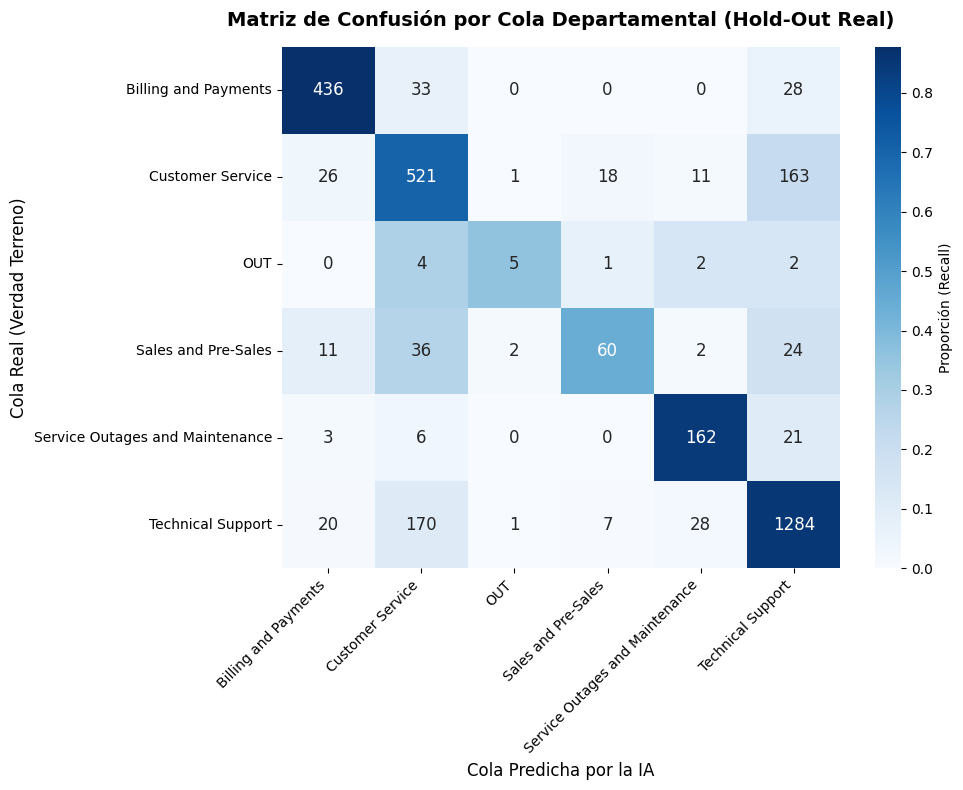

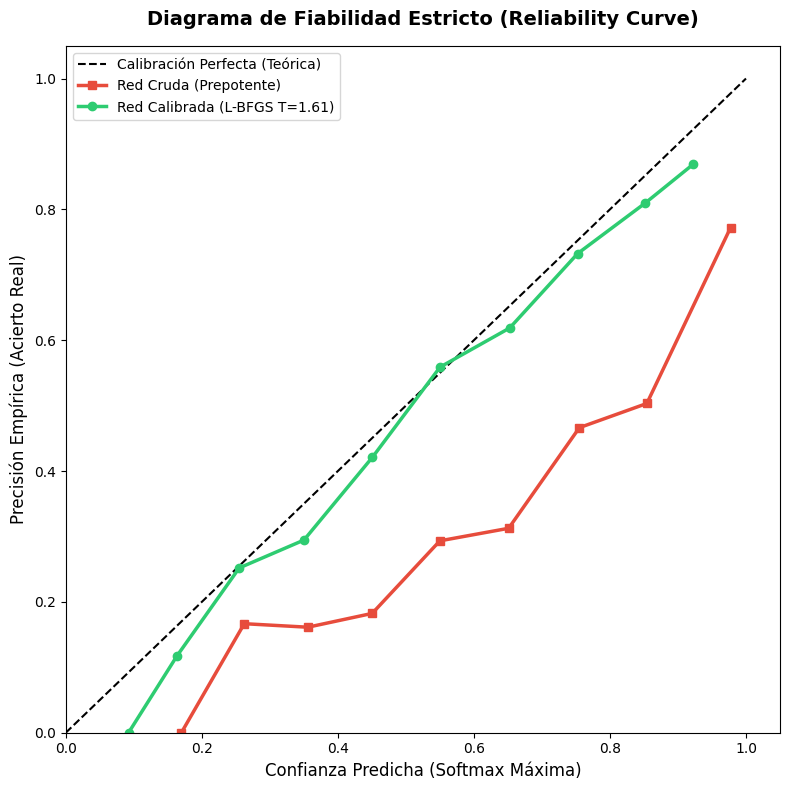


[LIME] Analizando semántica de Ticket con máxima confianza encontrada (0.96)...
[LIME] Analizando semántica de Ticket con peor confianza encontrada (0.00)...
✅ Análisis LIME exportado como páginas web interactiva (HTML) en la carpeta images.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch
from pathlib import Path

DIR_IMAGES = BASE_DIR / "images"
DIR_IMAGES.mkdir(exist_ok=True)

print("Generando auditoría forense de caja negra...")

# =========================================================
# GRÁFICA 3: Matriz de Confusión de Colas Marginalizadas
# =========================================================
plt.figure(figsize=(10, 8))
colas_unicas = sorted(list(set(df_resultados['true_cola'].unique()) | set(df_resultados['pred_cola'].unique())))

cm = confusion_matrix(df_resultados['true_cola'], df_resultados['pred_cola'], labels=colas_unicas)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)

sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', xticklabels=colas_unicas, yticklabels=colas_unicas,
            cbar_kws={'label': 'Proporción (Recall)'}, annot_kws={"size": 12})

plt.title("Matriz de Confusión por Cola Departamental (Hold-Out Real)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Cola Predicha por la IA", fontsize=12)
plt.ylabel("Cola Real (Verdad Terreno)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

ruta_cm = DIR_IMAGES / "confusion_matrix_colas.png"
plt.savefig(ruta_cm, dpi=300)
plt.show()

# =========================================================
# GRÁFICA 4: Diagrama de Fiabilidad (Calibration Curve)
# =========================================================
probs_crudas = torch.nn.functional.softmax(logits_tensor, dim=-1).numpy()

confianzas_crudas = np.max(probs_crudas, axis=1)
aciertos_crudos = (np.argmax(probs_crudas, axis=1) == labels_tensor.numpy()).astype(int)

confianzas_calibradas = np.max(probs_calibradas, axis=1)
aciertos_calibrados = (np.argmax(probs_calibradas, axis=1) == labels_tensor.numpy()).astype(int)

def compute_calibration_bins(confidences, accuracies, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1
    bin_accs, bin_confs = [], []
    for i in range(num_bins):
        mask = bin_indices == i
        if np.any(mask):
            bin_accs.append(np.mean(accuracies[mask]))
            bin_confs.append(np.mean(confidences[mask]))
    return bin_confs, bin_accs

crudos_confs, crudos_accs = compute_calibration_bins(confianzas_crudas, aciertos_crudos)
calib_confs, calib_accs = compute_calibration_bins(confianzas_calibradas, aciertos_calibrados)

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label="Calibración Perfecta (Teórica)")
plt.plot(crudos_confs, crudos_accs, 's-', color='#e74c3c', label="Red Cruda (Prepotente)", linewidth=2.5)
plt.plot(calib_confs, calib_accs, 'o-', color='#2ecc71', label=f"Red Calibrada (L-BFGS T={T_opt:.2f})", linewidth=2.5)

plt.title("Diagrama de Fiabilidad Estricto (Reliability Curve)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Confianza Predicha (Softmax Máxima)", fontsize=12)
plt.ylabel("Precisión Empírica (Acierto Real)", fontsize=12)
plt.legend(loc="upper left", fontsize=10)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.tight_layout()

ruta_calib = DIR_IMAGES / "calibration_curve.png"
plt.savefig(ruta_calib, dpi=300)
plt.show()

# =========================================================
# GRÁFICA 5: EXPLICABILIDAD DE TOKENS (LIME)
# =========================================================
from lime.lime_text import LimeTextExplainer

def predict_proba_lime(textos_list):
    inputs = tokenizer(textos_list, padding=True, truncation=True, max_length=256, return_tensors="pt").to(dispositivo)
    with torch.no_grad():
        logits_out = modelo(**inputs).logits
        probs_out = torch.nn.functional.softmax(logits_out / T_opt, dim=-1)
    return probs_out.cpu().numpy()

clases_ordenadas = [v for k, v in sorted(id2label.items())]
explainer = LimeTextExplainer(class_names=clases_ordenadas)

# Al bajar la confianza drásticamente, extraemos el mejor y el peor ticket
idx_claro = df_resultados['confianza_cola'].idxmax()
idx_dudoso = df_resultados['confianza_cola'].idxmin()

print(f"\n[LIME] Analizando semántica de Ticket con máxima confianza encontrada ({df_resultados.loc[idx_claro, 'confianza_cola']:.2f})...")
exp_claro = explainer.explain_instance(textos[idx_claro], predict_proba_lime, num_features=6, top_labels=1, num_samples=5000)
exp_claro.save_to_file(str(DIR_IMAGES / "lime_ticket_max_confianza.html"))

print(f"[LIME] Analizando semántica de Ticket con peor confianza encontrada ({df_resultados.loc[idx_dudoso, 'confianza_cola']:.2f})...")
exp_dudoso = explainer.explain_instance(textos[idx_dudoso], predict_proba_lime, num_features=6, top_labels=1, num_samples=5000)
exp_dudoso.save_to_file(str(DIR_IMAGES / "lime_ticket_peor_confianza.html"))

print(f"✅ Análisis LIME exportado como páginas web interactiva (HTML) en la carpeta images.")